In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense,LSTM, Dropout,Input, Concatenate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta



# Este dataframe contiene el total de los viajes realizados por linea de subte desde el año 2013 hasta el año 2020. 

- En el siguiente codigo, realizo la carga del dataset viajes_anual.csv, el cual contiene el total de viajes anuales desglosado por línea del sistema de transporte. 
- Posteriormente, se visualizan los primeros 10 registros utilizando df.head(10) para obtener una vista preliminar de la estructura y el contenido de los datos.

In [3]:
#CARGA DEL DATASET CON LA TOTALIDAD DE VIAJES ANUALES POR LINEA.
#VISUALIZO LOS PRIMEROS 10 REGISTROS

df=pd.read_csv("viajes_anual.csv")
df.head(10)


,year,LINEA,total
0,2013,A,26731478
1,2013,B,49458167
2,2013,C,27839180
3,2013,D,45532347
4,2013,E,11815541
5,2013,H,4377480
6,2014,A,48117121
7,2014,B,71550892
8,2014,C,41491009
9,2014,D,68188583


**VISUALIZACION, ANALISIS Y LIMPIEZA DE LOS DATOS**

- El siguiente codigo, realizo un análisis preliminar y conciso del DataFrame, incluyendo:
- •	El número total de entradas (filas).
- •	El rango del índice.
- •	Los nombres de las columnas y su tipo de dato (int64, float64, object, etc.).
- •	El número de valores no nulos por columna.
- •	El uso total de memoria.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    48 non-null     int64 
 1   LINEA   48 non-null     object
 2   total   48 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.3+ KB


- Luego, con el comando df.isnull().sum() visualizo el número total de valores nulos por columna en el DataFrame df.

- Este análisis permite identificar la presencia de datos incompletos que podrían afectar la calidad del análisis o modelo.
- A partir de estos resultados, se puede decidir si se imputan, eliminan o se manejan de otra forma las columnas o filas con valores faltantes.

In [5]:
df.isnull().sum()

year     0
LINEA    0
total    0
dtype: int64

In [6]:
print(df.isna().sum().sum())

0


- Luego, con el comando df.duplicated().sum() veo la cantidad total de filas duplicadas en el DataFrame df.

- Esto me permite identificar y cuantificar la redundancia en los datos pars luego poder analizar los pasos a seguir, lo cual es fundamental para asegurar la integridad y calidad del dataset antes de su análisis o modelado.

In [7]:
df.duplicated().sum()

0

In [8]:
df.dtypes



year      int64
LINEA    object
total     int64
dtype: object

- Finalmente, visualizo una muestra del dataframe.

In [9]:
df.columns


Index(['year', 'LINEA', 'total'], dtype='object')

In [10]:
df.sample(5)



,year,LINEA,total
46,2020,E,5270933
12,2015,A,54011706
15,2015,D,74073395
36,2019,A,63469412
23,2016,H,18163481


In [11]:
df.shape

(48, 3)

In [12]:
df.describe()


,year,total
count,48.000000,4.800000e+01
mean,2016.500000,4.372208e+07
std,2.315535,2.762894e+07
min,2013.000000,4.377480e+06
25%,2014.750000,1.898533e+07
50%,2016.500000,4.519574e+07
75%,2018.250000,6.474036e+07
max,2020.000000,9.201270e+07


**Visualizacion Grafica**

- Con el siguiente codigo, construyo una tabla dinámica (pivot_table) que agrupa el total de viajes anuales por línea, utilizando como índice el año. 
- Esta estructura permite visualizar la evolución temporal del volumen de viajes por línea. 
- Finalmente se grafica esta información mediante un gráfico de líneas, facilitando la comparación de tendencias y patrones entre las distintas líneas a lo largo del tiempo.

Total de viajes por LINEA por AÑO.
LINEA         A         B         C         D         E         H
year                                                             
2013   26731478  49458167  27839180  45532347  11815541   4377480
2014   48117121  71550892  41491009  68188583  18368628   7473392
2015   54011706  80973803  44859132  74073395  19190895   9410189
2016   58786268  86447290  46713260  83000815  21307077  18163481
2017   61943401  88723480  48163289  81600202  22085643  26185710
2018   63590948  92012699  54965093  82042036  22890867  32898471
2019   63469412  87449121  50661307  80941537  24097320  34721804
2020   11547922  16221726   7989026  14540456   5270933   6766380
Cantidad de viajes por Linea por Año


<Figure size 1800x1500 with 0 Axes>

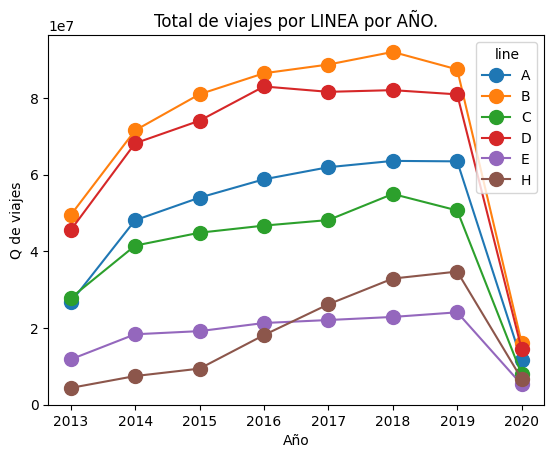

In [13]:
#CREO UNA TABLA CON EL TOTAL DE VIAJES POR AÑO POR LINEA Y LO GRAFICO PARA VER SU COMPORTAMIENTO.

lineapass=df.pivot_table(index='year',columns='LINEA', values='total',aggfunc='sum') 
print('Total de viajes por LINEA por AÑO.')
pd.set_option('display.width',1000)
print(lineapass)

plt.figure(figsize=(18,15))
lineapass.plot(kind='line', marker='o', markersize=10)
plt.title('Total de viajes por LINEA por AÑO.')
plt.xlabel('Año')
plt.ylabel('Q de viajes')
plt.legend(title='line')
print('Cantidad de viajes por Linea por Año')
plt.show()



**Algunas Conclusiones**

- El siguiente codigo, calculo la suma total de viajes por año a través de todas las líneas. 
- Luego, identifico el año con mayor y menor cantidad de viajes

In [22]:
suma_anual = lineapass.sum(axis=1)
maxpax = suma_anual.idxmax()
print(f'El año con mayor cantidad de viajes acumulados es {maxpax} con un total de {suma_anual.max()} viajes')

suma_anual = lineapass.sum(axis=1)
minpax = suma_anual.idxmin()
print(f'El año con menor cantidad de viajes acumulados es {minpax} con un total de {suma_anual.min()} viajes')

El año con mayor cantidad de viajes es 2018 con un total de 348400114 viajes
El año con menor cantidad de viajes es 2020 con un total de 62336443 viajes


**Visuaizacion Grafica**

- En el siguiente codigo, genero una tabla dinámica que muestra el total de viajes por línea para cada año, lo que facilita el análisis comparativo entre líneas. 
- A continuación, se representa esta información mediante un gráfico de líneas para observar tendencias, patrones y variaciones en la demanda por línea a lo largo del tiempo. 
- Esta visualización permite identificar cuáles líneas concentraron mayor volumen de pasajeros en distintos períodos.

Rankng LINEAS con mas viajes
year       2013      2014      2015      2016      2017      2018      2019      2020
LINEA                                                                                
A      26731478  48117121  54011706  58786268  61943401  63590948  63469412  11547922
B      49458167  71550892  80973803  86447290  88723480  92012699  87449121  16221726
C      27839180  41491009  44859132  46713260  48163289  54965093  50661307   7989026
D      45532347  68188583  74073395  83000815  81600202  82042036  80941537  14540456
E      11815541  18368628  19190895  21307077  22085643  22890867  24097320   5270933
H       4377480   7473392   9410189  18163481  26185710  32898471  34721804   6766380
Cantidad de viajes por Linea por Año


<Figure size 1200x1000 with 0 Axes>

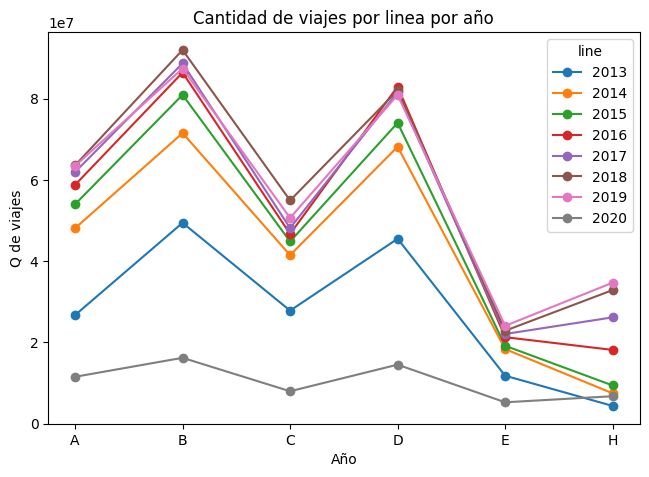

In [15]:
#CREO UNA TABLA CON EL TOTAL DE VIAJES POR LINEA POR AÑO Y LO GRAFICO PARA VER SU COMPORTAMIENTO.

lineapass2=df.pivot_table(index='LINEA',columns='year', values='total',aggfunc='sum') 
print('Rankng LINEAS con mas viajes')
pd.set_option('display.width',1000)
print(lineapass2)

plt.figure(figsize=(12,10))
lineapass2.plot(kind='line', marker='o')
plt.tight_layout()
plt.title('Cantidad de viajes por linea por año')
plt.xlabel('Año')
plt.ylabel('Q de viajes')
plt.legend(title='line')
print('Cantidad de viajes por Linea por Año')
plt.show()

- En el siguiente grafico, calculo el total acumulado de viajes por línea a lo largo de todos los años registrados. 
- Luego identifico las líneas con mayor y menor volumen de pasajeros.
- Esto me permite determinar cuáles líneas concentran la mayor demanda del sistema y cuáles presentan menor utilización histórica.

In [16]:
suma_linea= lineapass2.sum(axis=1)
maxpax2 = suma_linea.idxmax()
print(f'La Linea con mayor cantidad de viajes acumulados es la {maxpax2} con un total de {suma_linea.max()} viajes')

suma_linea = lineapass2.sum(axis=1)
minpax2 = suma_linea.idxmin()
print(f'La Linea con menor cantidad de viajes acumulados es la {minpax2} con un total de {suma_linea.min()} viajes')

La Linea con mayor cantidad de viajes es la B con un total de 572837178 viajes
La Linea con menor cantidad de viajes es la H con un total de 139996907 viajes


- Luego, genero gráficos de barras individuales para cada año entre 2014 y 2020, donde se visualiza el total de viajes por línea.
- Esta descomposición anual permite identificar cambios en el comportamiento de la demanda por línea, facilitando la detección de tendencias, picos o caídas específicas en determinados periodos.
- La visualización conjunta mejora la comparación entre años y líneas dentro del sistema de transporte.

Total de viajes por Año por linea


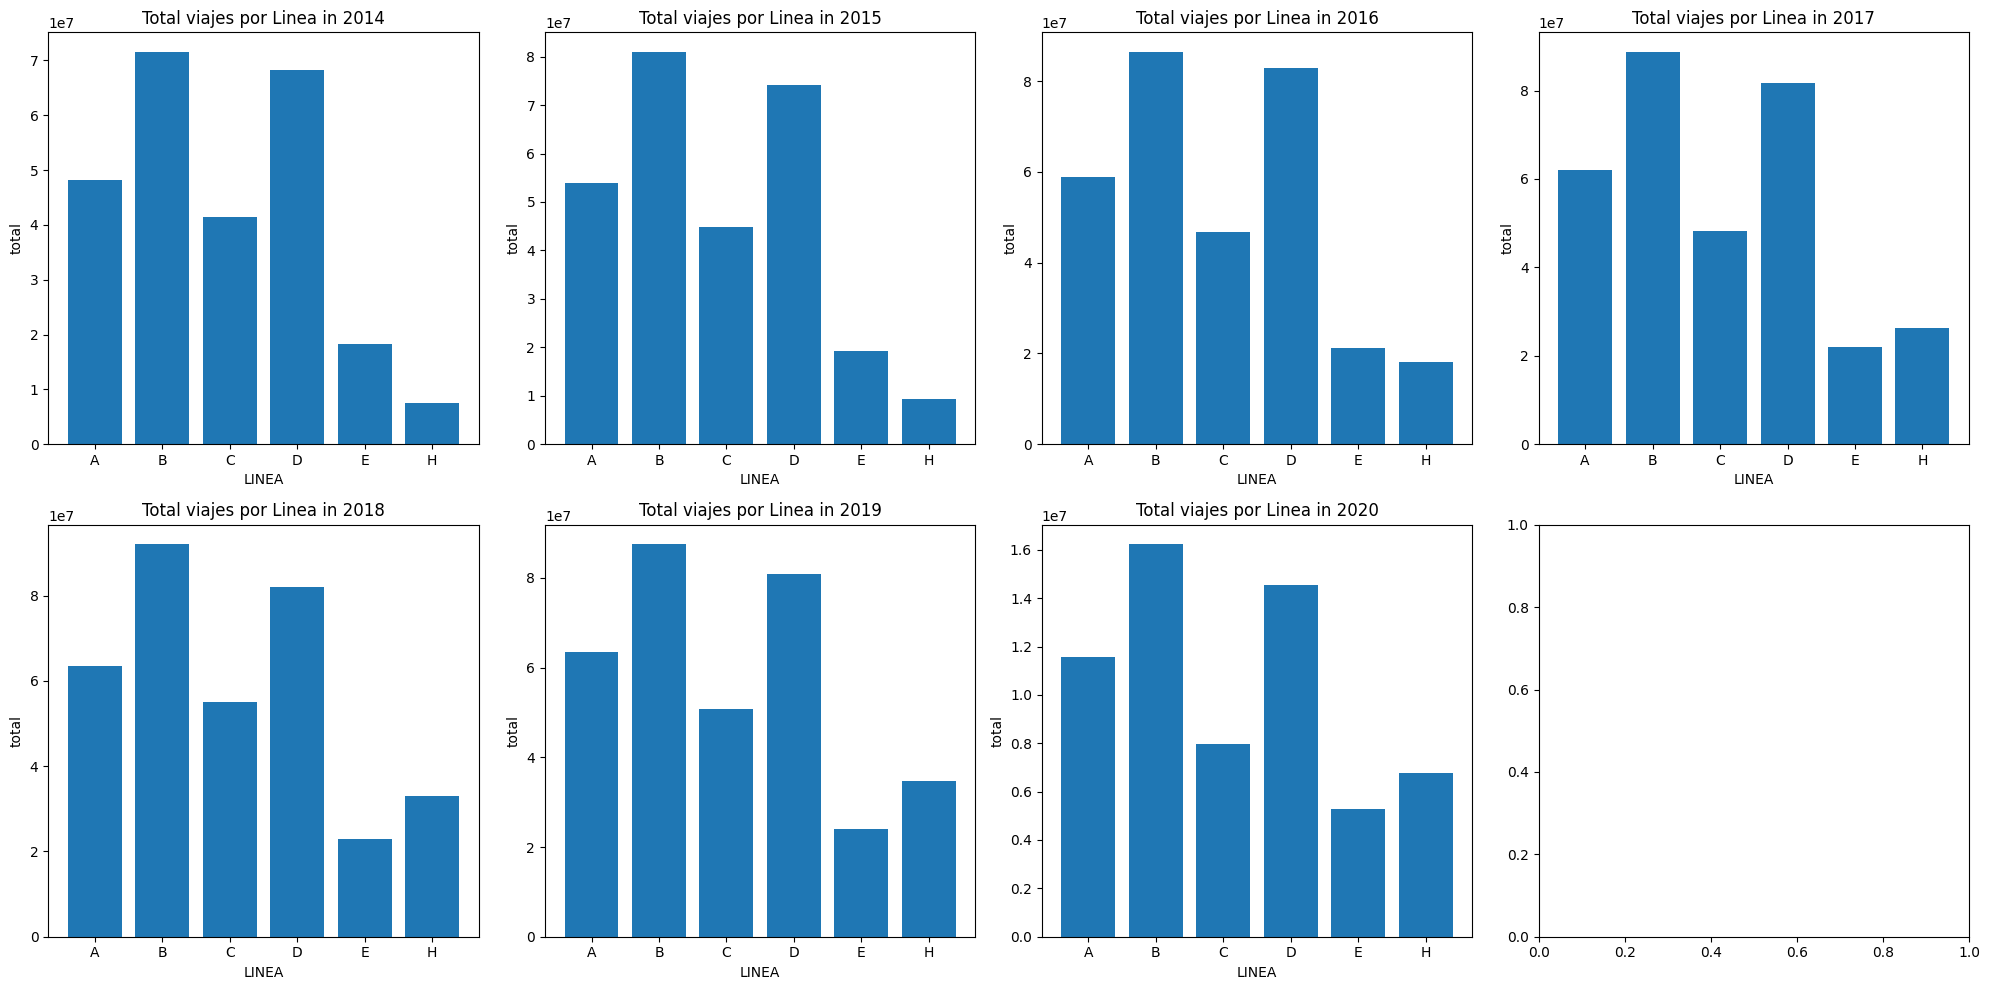

In [17]:
#CREO GRAFICOS POR AÑO APERTURADO POR LINEA VER EL COMPORTAMIENTO DEL TOTAL DE VIAJES.  

fig,axs = plt.subplots(2,4, figsize=(20,10))

for i, year in enumerate(range (2014,2021)):
        ax = axs[i // 4, i%4]
        ax.bar(df.loc[df['year'] == year, 'LINEA'], df.loc[df['year'] == year, 'total'])
        ax.set_title(f'Total viajes por Linea in {year}')
        ax.set_xlabel('LINEA')
        ax.set_ylabel('total')
print('Total de viajes por Año por linea')
plt.tight_layout()
plt.show()


- A continuacion, genero gráficos de barras para cada línea de transporte (A, B, C, D, E, H), mostrando el total de viajes por año entre 2014 y 2020. 
- Estos gráficos permiten visualizar cómo varió la demanda por línea en cada año.
- Esta visualización es útil para comparar el comportamiento de cada línea a lo largo de los años.

Total de viajes por linea aperturado por Año


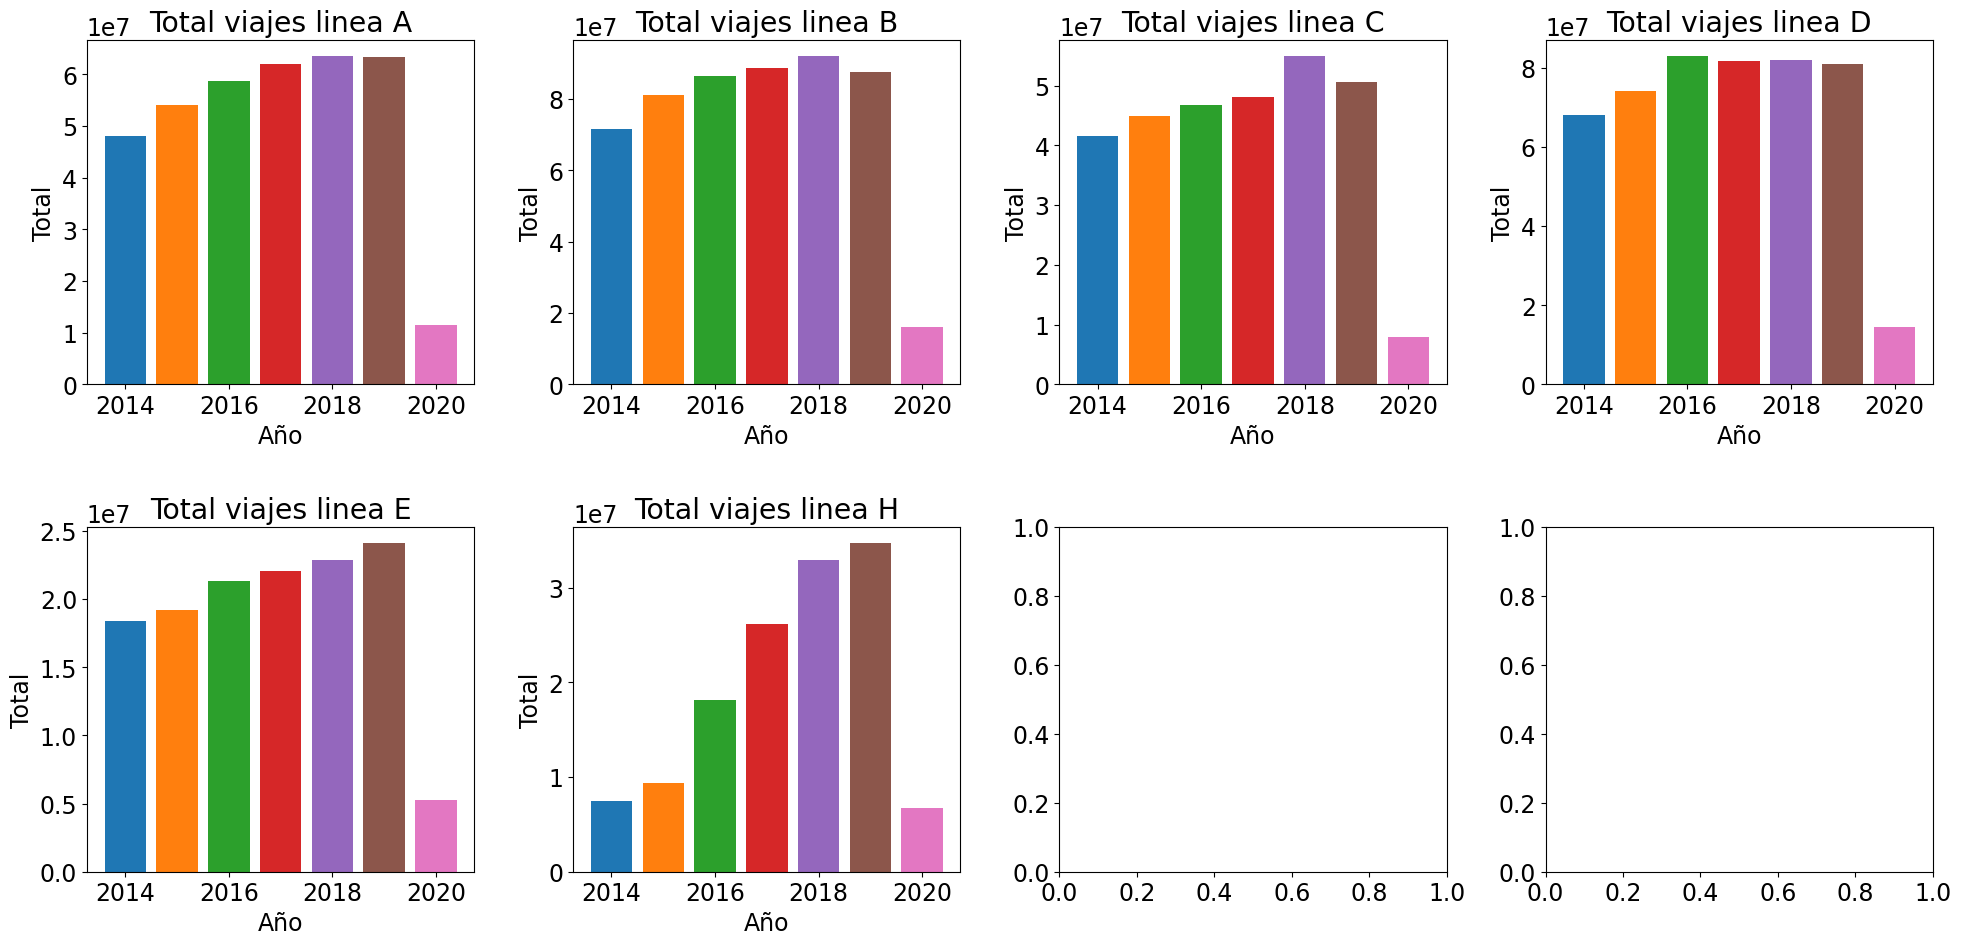

In [23]:
#CREO GRAFICOS POR AÑO APERTURADO POR LINEA VER EL COMPORTAMIENTO DEL TOTAL DE VIAJES. 

fig,axs = plt.subplots(2,4, figsize=(20,10))
LINEAS =['A', 'B','C','D','E','H']
for i, LINEA in enumerate(LINEAS):
        ax = axs[i // 4, i%4]
        for year in range (2014,2021):
                ax.bar(year, df.loc[(df['LINEA'] == LINEA) & (df['year'] == year), 'total'])
        ax.set_title(f'Total viajes linea {LINEA}')
        ax.set_xlabel('Año')
        ax.set_ylabel('Total')
plt.tight_layout()
print('Total de viajes por linea aperturado por Año')
plt.show()

- A continuacion, creo gráficos de torta para cada línea de subte, mostrando la distribución de pasajeros por año entre 2014 y 2020. 
- La explosión se aplica al año 2020 para destacarlo, dado el impacto de la pandemia en ese período. 
- Esta visualización permite analizar la proporción de pasajeros por año, destacando las variaciones significativas, como el descenso en 2020.

2020 Pandemia


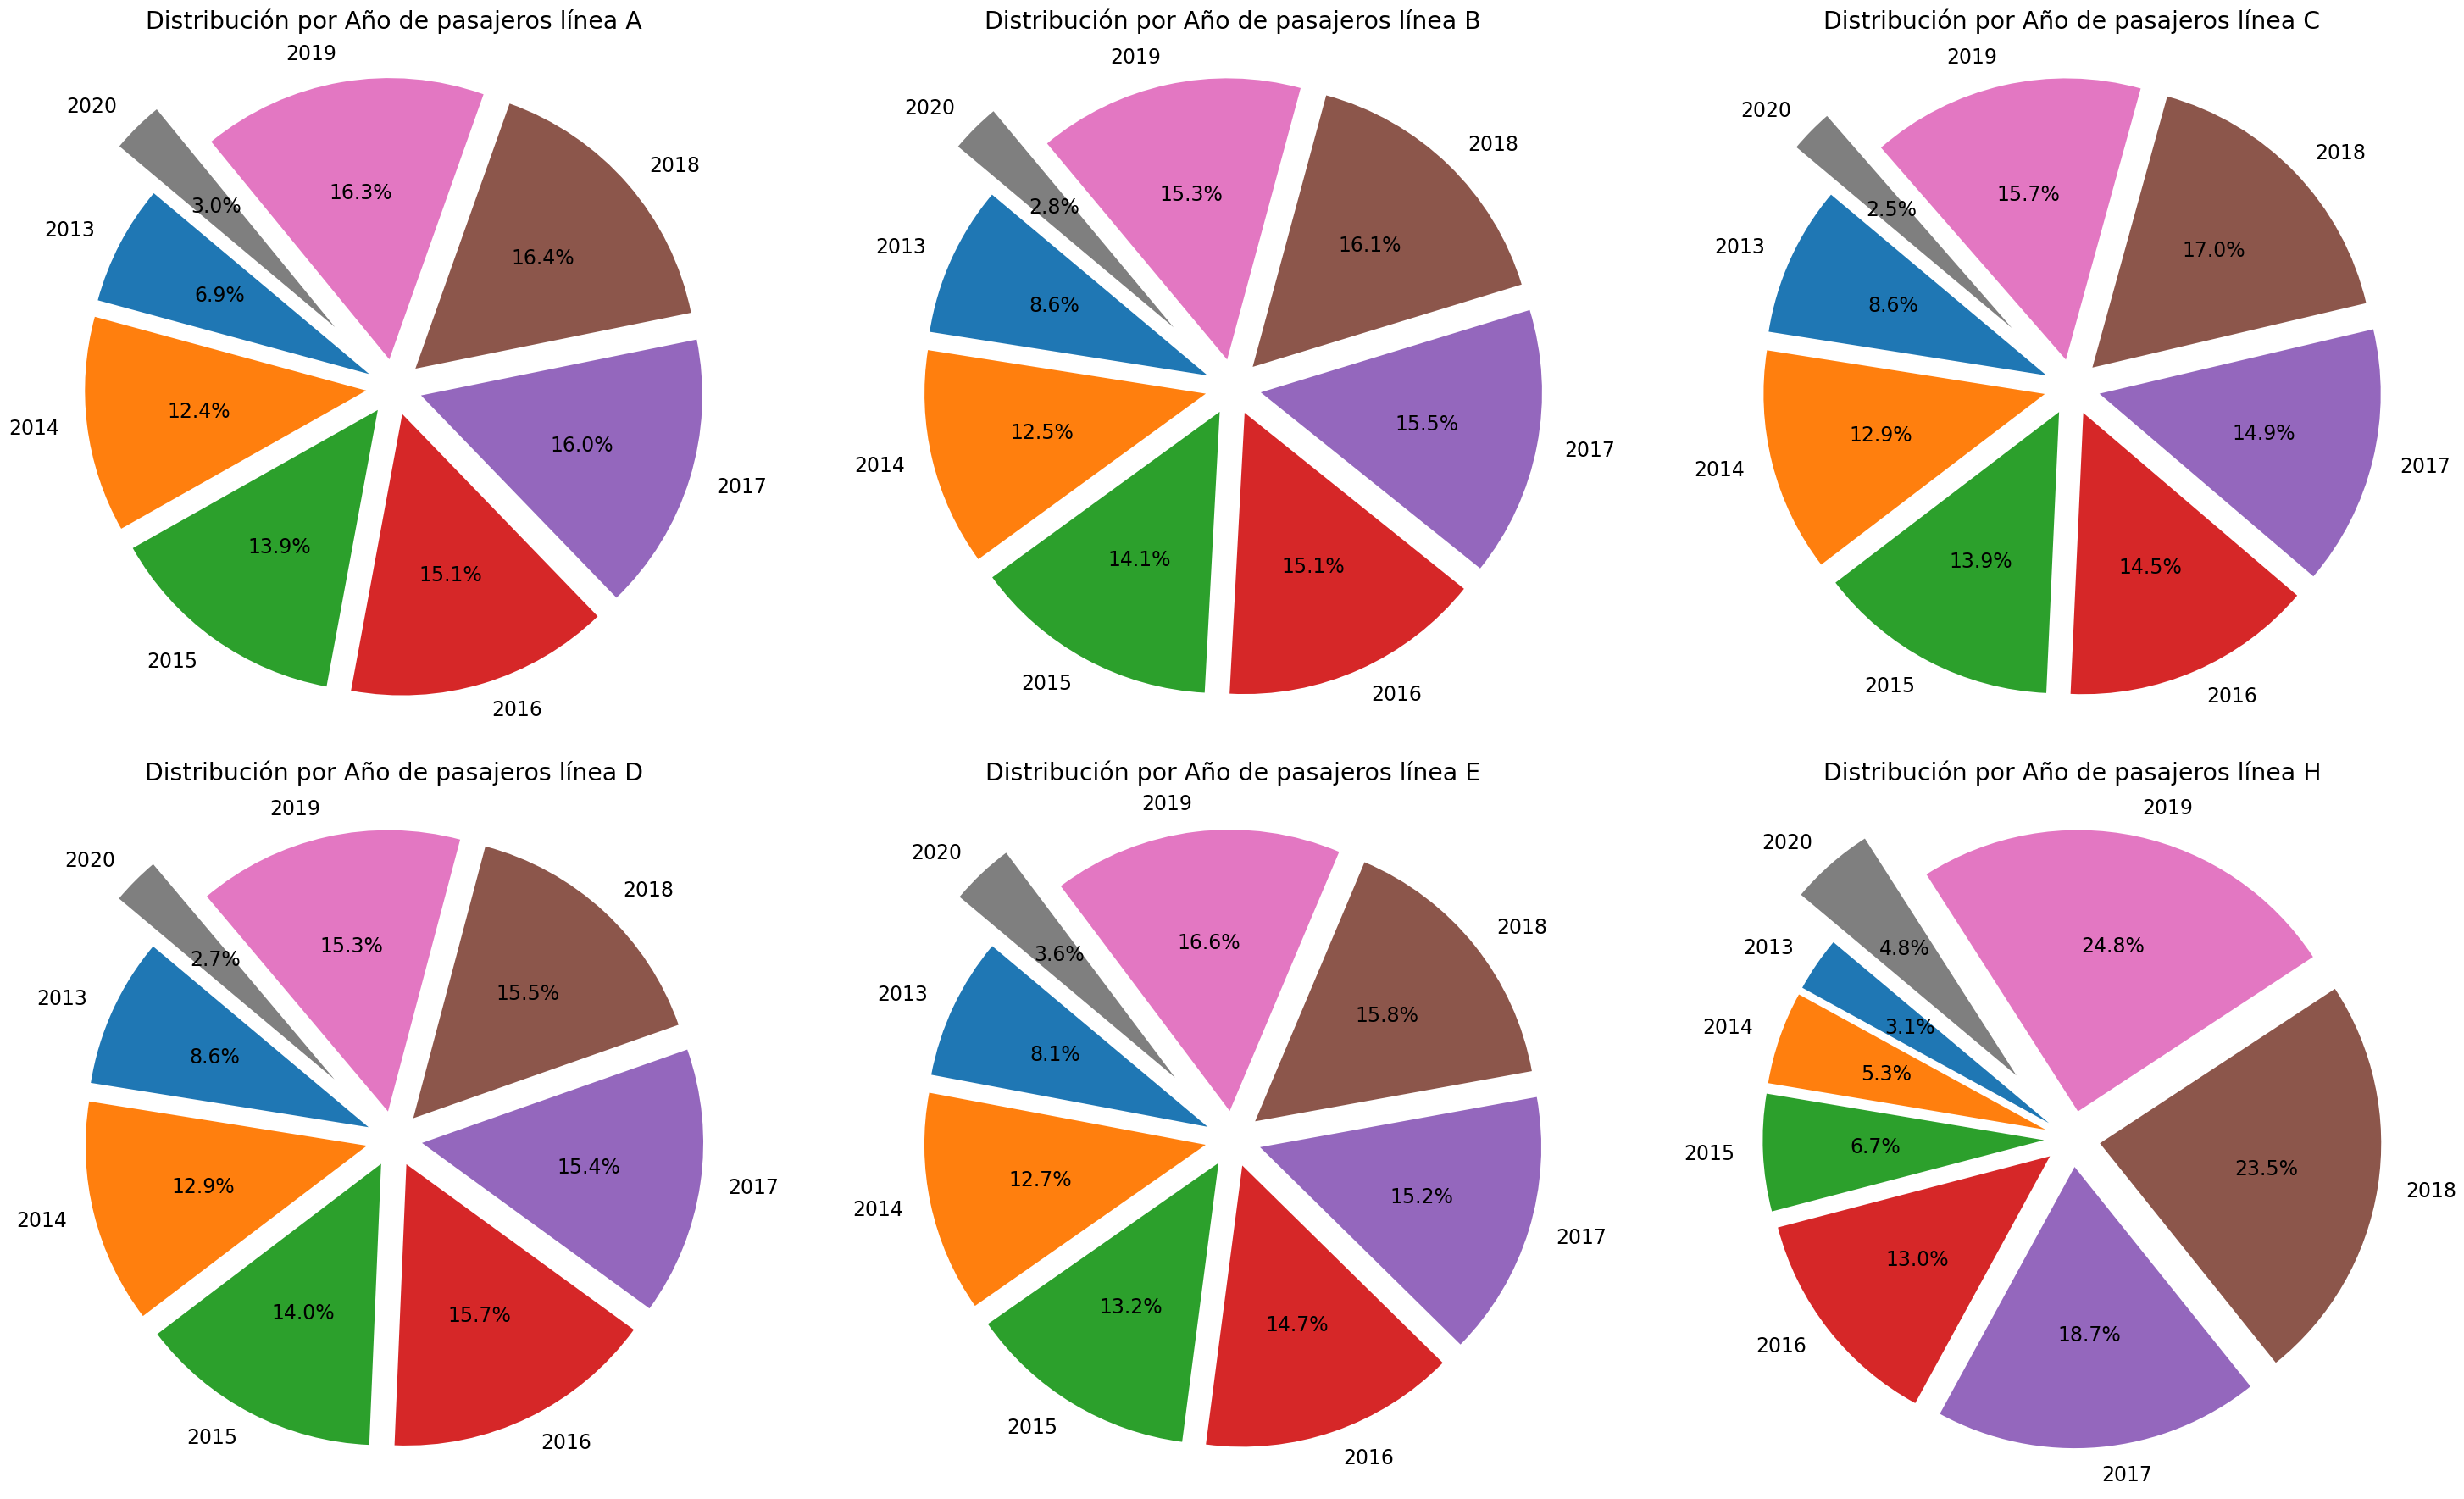

In [24]:
fig, axs = plt.subplots(2, 3, figsize=(30, 18))
LINEAS = ['A', 'B', 'C', 'D', 'E', 'H']

for i, LINEA in enumerate(LINEAS):
    ax = axs[i // 3, i % 3]
    datos = df.loc[df['LINEA'] == LINEA, 'total'].groupby(df['year']).sum()
    explosion = [0.3 if year == 2020 else 0.1 for year in datos.index]  # Explosión para 2020
    ax.pie(datos, labels=datos.index, autopct='%1.1f%%', startangle=140, explode=explosion)
    ax.set_title(f'Distribución por Año de pasajeros línea {LINEA}')
    
print('2020 Pandemia')
plt.tight_layout()
plt.show()

- Por ultimo, genero gráficos de torta que muestran la distribución porcentual de viajes por línea para cada año. 
- Se destaca con mayor explosión la línea con mayor y con menor viajes, facilitando la interpretación visual. 
- Esta representación nos permite observar la participación relativa de cada línea en distintos años y detectar cambios significativos en la demanda.

APERTURA de viajes por línea por año


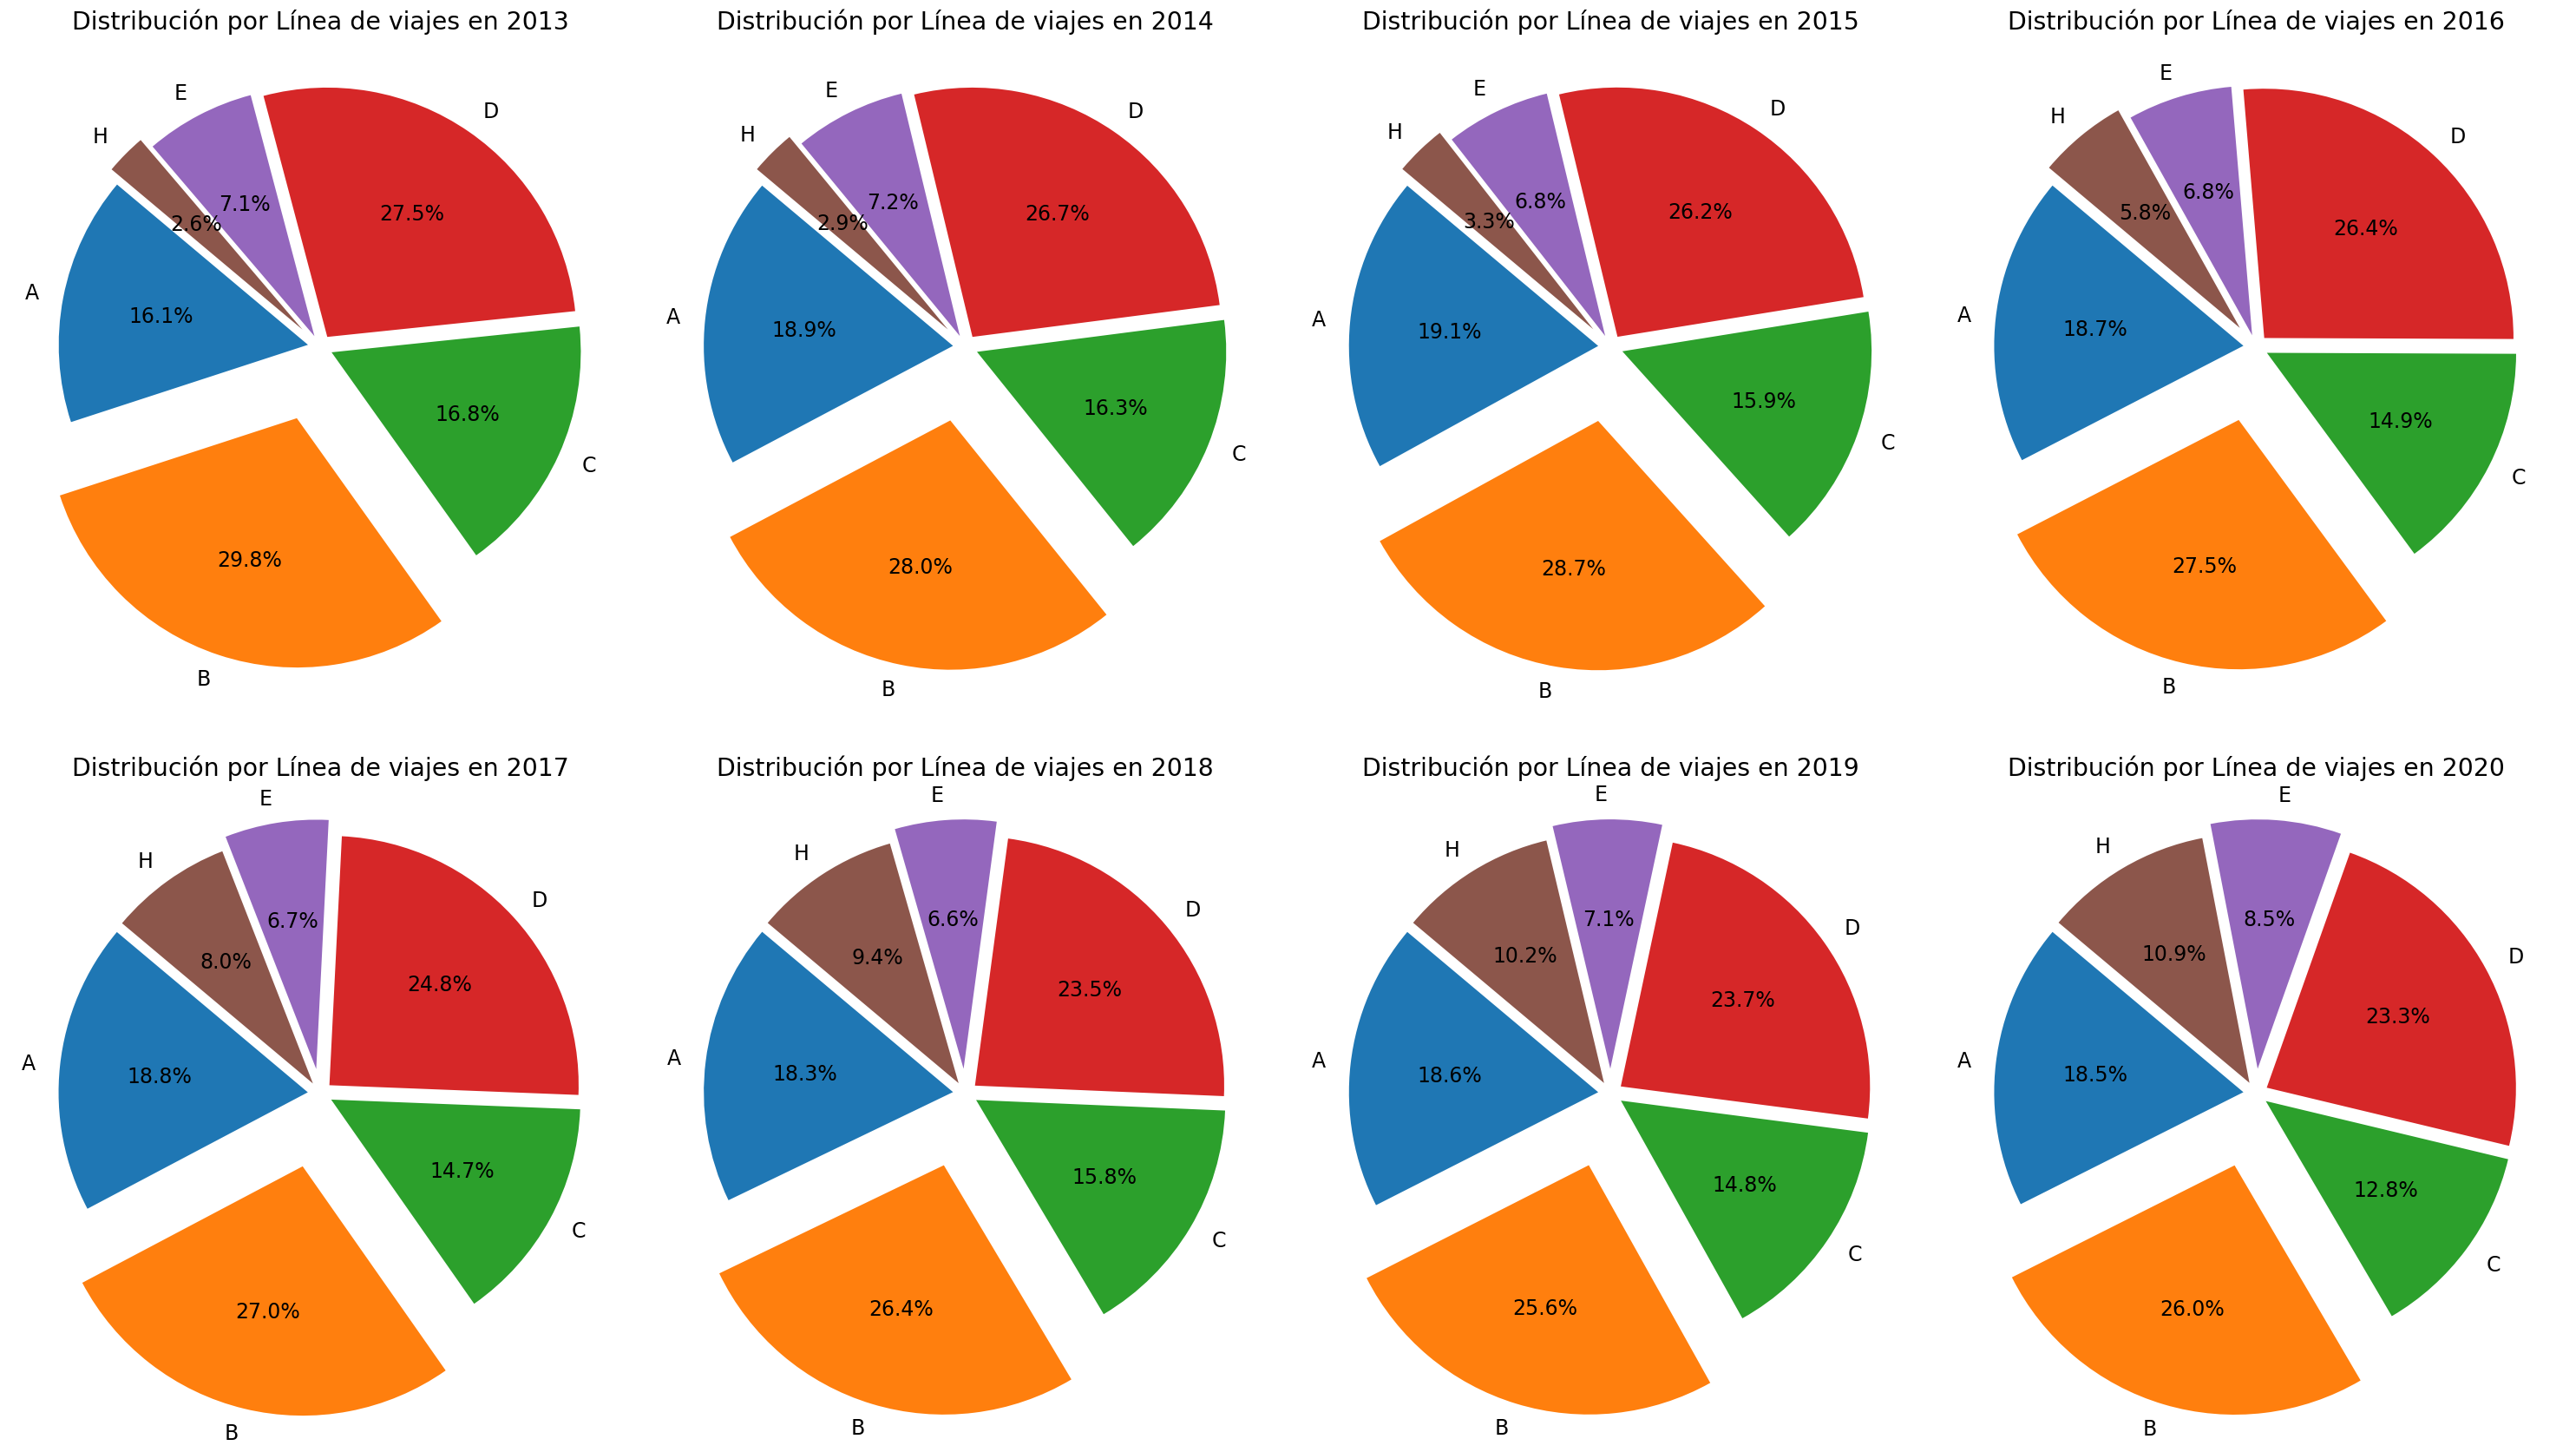

In [25]:
anos = df['year'].unique()
fig, axs = plt.subplots(2, 4, figsize=(30, 18))

for idx, ano in enumerate(anos):
    ax = axs[idx // 4, idx % 4]
    datos = df.loc[df['year'] == ano, 'total'].groupby(df['LINEA']).sum()
    max_index = datos.idxmax()
    min_index = datos.idxmin()
    explosion = [0.3 if linea == max_index else 0.1 if linea == min_index else 0.05 for linea in datos.index]
    ax.pie(datos, labels=datos.index, autopct='%1.1f%%', startangle=140, explode=explosion)
    ax.set_title(f'Distribución por Línea de viajes en {ano}')

print('APERTURA de viajes por línea por año')
plt.rcParams['font.size'] = 17
plt.tight_layout()
plt.show()

**CONCLUSIONES FINALES**

In [26]:
print('=== Conclusiones ===\n')

linea_mayor_crecimiento = df.groupby('LINEA')['total'].mean().idxmax()
print(f'- La línea con mayor crecimiento promedio anual es la: {linea_mayor_crecimiento}')

print(f'- El año con mayor cantidad de viajes fue {maxpax}, con un total de {suma_anual.max():,.0f} viajes')
print(f'- El año con menor cantidad de viajes fue {minpax}, con un total de {suma_anual.min():,.0f} viajes')

print(f'- La línea con mayor cantidad de viajes acumulados fue la {maxpax2}, con {suma_linea.max():,.0f} viajes')
print(f'- La línea con menor cantidad de viajes acumulados fue la {minpax2}, con {suma_linea.min():,.0f} viajes')

=== Conclusiones ===

- La línea con mayor crecimiento promedio anual es la: B
- El año con mayor cantidad de viajes fue 2018, con un total de 348,400,114 viajes
- El año con menor cantidad de viajes fue 2020, con un total de 62,336,443 viajes
- La línea con mayor cantidad de viajes acumulados fue la B, con 572,837,178 viajes
- La línea con menor cantidad de viajes acumulados fue la H, con 139,996,907 viajes
